# 1. Análise Exploratória

In [ ]:
from matplotlib.artist import get
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

# Não limitar o tamanho da resposta
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

train_csv = pd.read_csv("data/train.csv")

def get_outlier(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3-q1

    lim_sup = q3+(iqr*1.5)
    lim_inf = q1-(iqr*1.5)

    return series[(series < lim_inf) | (series > lim_sup)]

def set_outliers(series: pd.Series):
    if not pd.api.types.is_numeric_dtype(series.dtype):
        return "Não elegível"

    if get_outlier(series).any():
        return "Sim"
    return "Não"

## 1.1 Distribuição das Variáveis

In [34]:
exploracao_csv = pd.DataFrame(
    {
        "categoria": train_csv.dtypes.map(lambda x: "Numérico" if x.kind in "iufc" else "Categórico"),
        "tem_null": train_csv.isna().sum().map(lambda x: "Sim" if x >= 1 else "Não"),
        "tem_outliers": train_csv.apply(set_outliers)
    }
)

exploracao_csv

,categoria,tem_null,tem_outliers
Id,Numérico,Não,Não
MSSubClass,Numérico,Não,Sim
MSZoning,Categórico,Não,Não elegível
LotFrontage,Numérico,Sim,Sim
LotArea,Numérico,Não,Sim
Street,Categórico,Não,Não elegível
Alley,Categórico,Sim,Não elegível
LotShape,Categórico,Não,Não elegível
LandContour,Categórico,Não,Não elegível
Utilities,Categórico,Não,Não elegível


## 1.2 Correlações e Dispersões
### 1.2.1 Correlações com a variável de preço da propriedade (SalePrice)

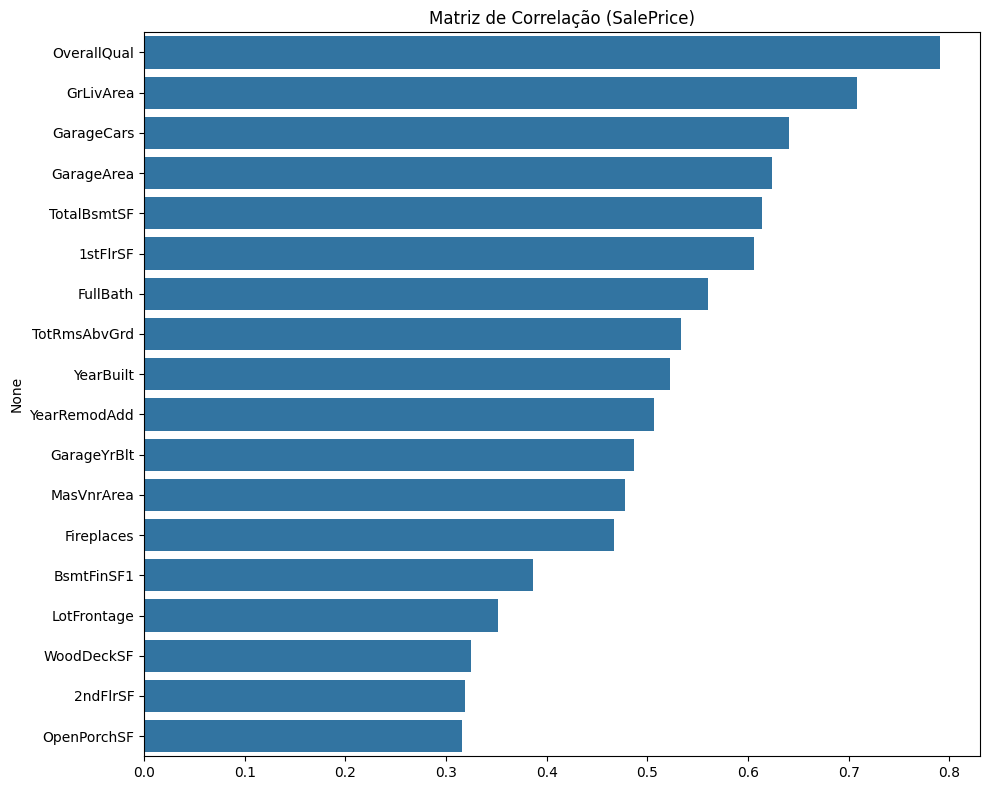

In [64]:
corr = train_csv.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False).drop("SalePrice")

corr = corr.to_frame(name="correlation")
corr["abs_correlation"] = corr["correlation"].abs()

# Pega todas as variáveis com correlação absoluta maior que 0.3
best_corr = corr[corr["abs_correlation"] >= 0.3].sort_values(by="abs_correlation", ascending=False)

plt.figure(figsize=(10, 8))
sb.barplot(
    x=best_corr["correlation"].values,
    y=best_corr.index,
)
plt.title("Matriz de Correlação (SalePrice)")
plt.tight_layout()
plt.show()



### 1.2.2 Dispersão entre a área da propriedade e o preço (GrLivArea x SalePrice)

      GrLivArea  SalePrice
0          1710     208500
1          1262     181500
2          1786     223500
3          1717     140000
4          2198     250000
5          1362     143000
6          1694     307000
7          2090     200000
8          1774     129900
9          1077     118000
10         1040     129500
11         2324     345000
12          912     144000
13         1494     279500
14         1253     157000
15          854     132000
16         1004     149000
17         1296      90000
18         1114     159000
19         1339     139000
20         2376     325300
21         1108     139400
22         1795     230000
23         1060     129900
24         1060     154000
25         1600     256300
26          900     134800
27         1704     306000
28         1600     207500
29          520      68500
30         1317      40000
31         1228     149350
32         1234     179900
33         1700     165500
34         1561     277500
35         2452     309000
3

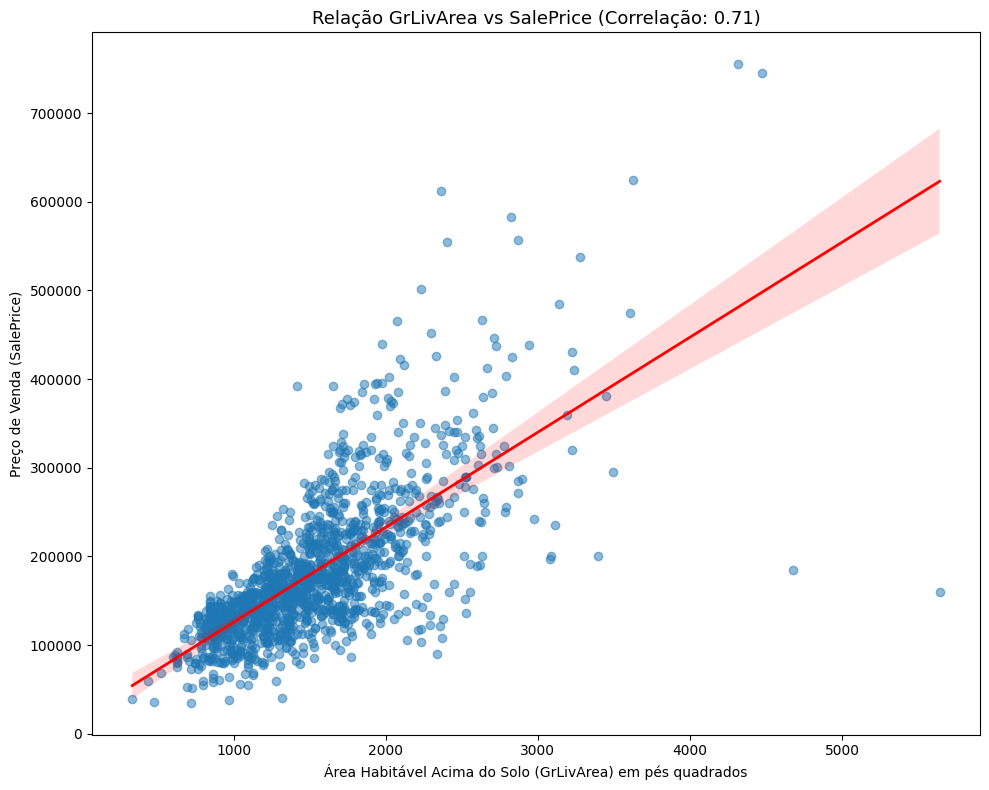

In [71]:
corr: pd.DataFrame = train_csv["GrLivArea"].corr(train_csv["SalePrice"])

corr_matrix = train_csv[["GrLivArea", "SalePrice"]]

corr_matrix["SalePrice"].apply(lambda x: "$" + str(x))
print(corr_matrix)

plt.figure(figsize=(10,8))
sb.regplot(
    data=train_csv,
    x="GrLivArea",
    y="SalePrice",
    scatter_kws={"alpha":0.5, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title(f"Relação GrLivArea vs SalePrice (Correlação: {corr:.2f})", fontsize=13)
plt.xlabel("Área Habitável Acima do Solo (GrLivArea) em pés quadrados")
plt.ylabel("Preço de Venda (SalePrice)")
plt.tight_layout()
plt.show()